In [1]:
import numpy as np
import matplotlib.pyplot as plt

def arbol_crr(S0, K, r, T, sigma, N, option='call', style='european'):
    """
    Árbol binomial CRR para opciones europeas o americanas.

    S0     : precio inicial
    K      : strike
    r      : tasa libre de riesgo
    T      : tiempo al vencimiento en años
    sigma  : volatilidad
    N      : número de pasos
    option : 'call' o 'put'
    style  : 'european' o 'american'
    """
    dt = T / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1 / u
    p  = (np.exp(r * dt) - d) / (u - d)
    df = np.exp(-r * dt)   # factor de descuento por paso

    # --- Árbol de precios al vencimiento ---
    # ST[i] = S0 * u^(N-i) * d^i  para i = 0, 1, ..., N
    ST = np.array([S0 * (u**(N-i)) * (d**i) for i in range(N+1)])

    # --- Valores de la opción al vencimiento ---
    if option == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    # --- Inducción hacia atrás ---
    for step in range(N-1, -1, -1):
        S_step = np.array([S0 * (u**(step-i)) * (d**i) for i in range(step+1)])

        # Valor de continuar (esperanza descontada)
        V_continuar = df * (p * V[:step+1] + (1-p) * V[1:step+2])

        if style == 'american':
            # Valor de ejercer ahora
            if option == 'call':
                V_ejercer = np.maximum(S_step - K, 0)
            else:
                V_ejercer = np.maximum(K - S_step, 0)
            V = np.maximum(V_continuar, V_ejercer)
        else:
            V = V_continuar

    return V[0]

# Parámetros
S0    = 669.03
K     = 680
r     = 0.042
T     = 31/365
sigma = 0.1687
N     = 100

precio_euro_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'european')
precio_amer_call = arbol_crr(S0, K, r, T, sigma, N, 'call', 'american')
precio_euro_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'european')
precio_amer_put  = arbol_crr(S0, K, r, T, sigma, N, 'put',  'american')

print(f"Call europea  : ${precio_euro_call:.4f}")
print(f"Call americana: ${precio_amer_call:.4f}  (prima por ejercicio anticipado: ${precio_amer_call - precio_euro_call:.4f})")
print(f"Put europea   : ${precio_euro_put:.4f}")
print(f"Put americana : ${precio_amer_put:.4f}  (prima por ejercicio anticipado: ${precio_amer_put - precio_euro_put:.4f})")

Call europea  : $9.3925
Call americana: $9.3925  (prima por ejercicio anticipado: $0.0000)
Put europea   : $17.9412
Put americana : $18.2479  (prima por ejercicio anticipado: $0.3068)


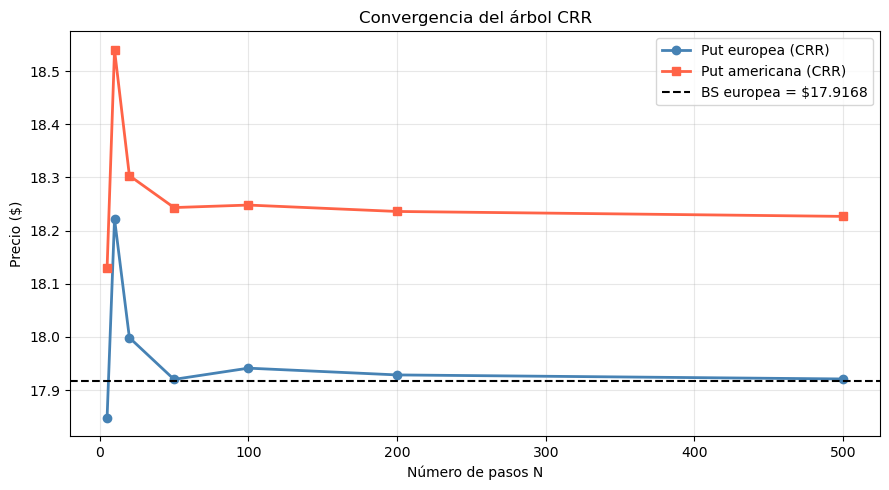

In [2]:
# Precio vs. número de pasos
pasos   = [5, 10, 20, 50, 100, 200, 500]
precios_euro = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'european') for n in pasos]
precios_amer = [arbol_crr(S0, K, r, T, sigma, n, 'put', 'american') for n in pasos]

# Precio BS como referencia
from scipy.stats import norm
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)
bs_put = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)

plt.figure(figsize=(9, 5))
plt.plot(pasos, precios_euro, marker='o', color='steelblue',
         linewidth=2, label='Put europea (CRR)')
plt.plot(pasos, precios_amer, marker='s', color='tomato',
         linewidth=2, label='Put americana (CRR)')
plt.axhline(bs_put, color='black', linestyle='--',
            label=f'BS europea = ${bs_put:.4f}')
plt.xlabel('Número de pasos N')
plt.ylabel('Precio ($)')
plt.title('Convergencia del árbol CRR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

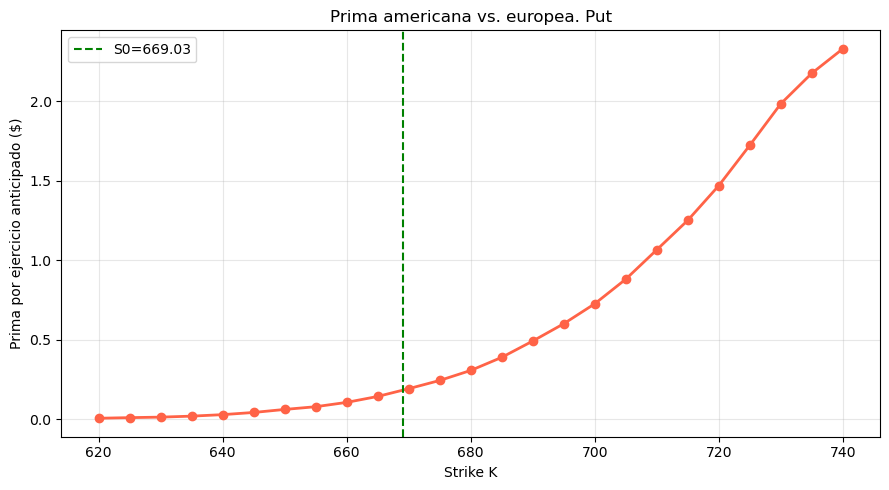

In [3]:
K_range      = np.arange(620, 741, 5)
prima_antic  = []

for k in K_range:
    euro = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'european')
    amer = arbol_crr(S0, k, r, T, sigma, 100, 'put', 'american')
    prima_antic.append(amer - euro)

plt.figure(figsize=(9, 5))
plt.plot(K_range, prima_antic, color='tomato', linewidth=2, marker='o')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Strike K')
plt.ylabel('Prima por ejercicio anticipado ($)')
plt.title('Prima americana vs. europea. Put')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

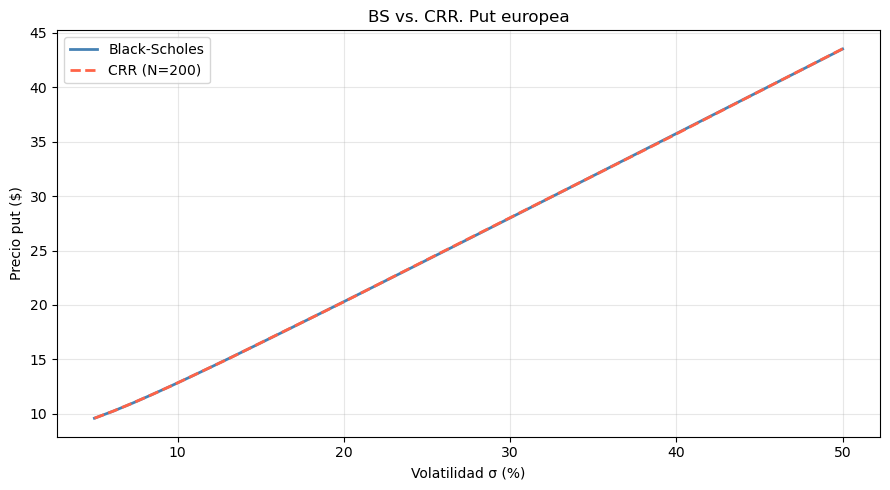

In [4]:
sigma_range  = np.linspace(0.05, 0.50, 40)
bs_precios   = []
crr_precios  = []

for s in sigma_range:
    d1 = (np.log(S0/K) + (r + 0.5*s**2)*T) / (s*np.sqrt(T))
    d2 = d1 - s*np.sqrt(T)
    bs_precios.append(K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1))
    crr_precios.append(arbol_crr(S0, K, r, T, s, 200, 'put', 'european'))

plt.figure(figsize=(9, 5))
plt.plot(sigma_range*100, bs_precios,  color='steelblue', linewidth=2,
         label='Black-Scholes')
plt.plot(sigma_range*100, crr_precios, color='tomato',    linewidth=2,
         linestyle='--', label='CRR (N=200)')
plt.xlabel('Volatilidad σ (%)')
plt.ylabel('Precio put ($)')
plt.title('BS vs. CRR. Put europea')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Preguntas

- ¿Por qué el ejercicio anticipado de una call sobre un activo sin dividendos nunca es óptimo? ¿Qué cambia si el activo paga dividendos?

Los resultados muestran que la call europea y la americana tienen el mismo precio 9.3925 con una prima por ejercicio anticipado de 0. Esto confirma que ejercer la call antes del vencimiento nunca agrega valor cuando el activo no paga dividendos. Esto ocurre porque, al hacerlo, se pierde el valor temporal de la opción y se adelanta el pago del precio de ejercicio, dejando de ganar intereses sobre ese dinero. En consecuencia, es mejor vender la opción que ejercerla antes del vencimiento. Si el activo paga dividendos, la situación cambia. Antes del pago del dividendo, el precio del activo tiende a disminuir, lo que reduce el valor de la call. En ese caso, puede ser conveniente ejercer anticipadamente para evitar esa pérdida, haciendo que la opción americana tenga mayor valor que la europea.

- En la gráfica de convergencia, ¿por qué el precio oscila antes de converger? ¿Qué relación tiene eso con si N es par o impar?

En la gráfica, el precio presenta oscilaciones cuando el número de pasos N es pequeño, pero se estabiliza conforme N aumenta. Esto se debe a si N es par o impar. Cuando N es par, el árbol incluye un nodo exactamente en el precio inicial, lo que mejora la precisión. En cambio, cuando N es impar, esto no ocurre, generando un pequeño error que cambia de signo entre valores consecutivos. Este comportamiento produce el patrón de oscilación. A medida que N crece, estas diferencias se vuelven insignificantes y el modelo converge al valor teórico.

- La prima por ejercicio anticipado es mayor para puts muy ITM. ¿Por qué intuitivamente tiene sentido ejercer anticipadamente una put muy ITM?

La gráfica de prima americana vs. europea muestra con claridad que la diferencia entre ambas opciones crece de forma acelerada conforme el strike K supera el precio actual So = 669.03, es decir, conforme la put está más dentro del dinero. Para K cercano a 620 la prima es prácticamente cero, mientras que para K = 740 supera los 2.30. Esto significa que cuando una put está muy ITM, su valor intrínseco es elevado y su valor temporal restante es pequeño, porque el precio del activo ya tiene poco margen para caer más. Al ejercer anticipadamente, el tenedor obtiene ese efectivo de inmediato y puede invertirlo a la tasa libre de riesgo, generando un rendimiento que supera el beneficio de mantener la opcionalidad viva. Cuanto mayor es el ITM, más atractivo resulta ese intercambio, lo que explica el crecimiento de la prima.

- Si modificas T primero a 31 días y luego a 1 año, ¿cómo esperas que cambie la diferencia entre la put americana y la europea? ¿Por qué?

Con T = 31/365 días, que es el parámetro usado, la prima por ejercicio anticipado es de 0.3068. Al reducir T a un horizonte aún menor, esta diferencia tendería a desaparecer porque habría menos períodos en los que ejercer anticipadamente podría ser beneficioso. En contraste, al ampliar T a 1 año, la diferencia entre la put americana y la europea aumentaría de forma significativa. La razón es doble: primero, con más tiempo disponible, existen más momentos potenciales en los que el ejercicio anticipado podría ser óptimo, segundo, el costo de oportunidad de no recibir el efectivo inmediatamente se acumula durante más tiempo, haciendo que la ventaja del ejercicio anticipado sea más valiosa. En resumen, a mayor plazo, mayor valor adicional tiene la flexibilidad americana sobre la europea.

- El árbol CRR usa probabilidades neutrales al riesgo p, no probabilidades reales. ¿Qué significa eso y por qué es válido para el pricing?

La probabilidad neutral al riesgo no representa la probabilidad real de que el activo suba. Se trata de una probabilidad artificial construida de tal manera que, bajo ella, el rendimiento esperado del activo es exactamente la tasa libre de riesgo r, como si todos los participantes del mercado fueran indiferentes al riesgo. Esta construcción es válida para el pricing porque el precio de una opción se determina por el principio de no-arbitraje: siempre existe una cartera compuesta por el activo subyacente y un bono libre de riesgo que replica exactamente los flujos de la opción. Al construir esa cartera replicante, las probabilidades reales, y las preferencias de riesgo de los inversionistas, se cancelan algebraicamente, y el único factor relevante es la tasa de descuento libre de riesgo. La gráfica BS vs. CRR valida empíricamente esta equivalencia, mostrando que ambos métodos producen precios prácticamente idénticos para la put europea en todo el rango de volatilidades analizado.